# Notebook 00 — Where does it actually rain?

### Forty-seven years of satellite rainfall, and one stubborn question

Start here. Before any theory, before any model, look at the data.

You are going to open a real climate data file — the same format every climate
model on Earth writes its output in — and make it show you something. By the end
you will have watched the rainiest band on the planet march north and south
across the equator through the seasons, measured exactly where it sits, and
arrived at the question this whole project is about.

**What you need to know going in:** nothing. Not Python, not meteorology.

**How to use this notebook.** Click a grey cell and press `Shift + Enter` to run
it. Run them **in order, top to bottom**. Scattered through are boxes labelled
**Your turn** — those are questions for you to answer in writing. Double-click
the box, type under the line, press `Shift + Enter`. Do not skip them; they are
the actual work. There are no wrong answers, only unobserved ones.

---

## Before you start — getting a working setup

You will run these notebooks in **VS Code**, the editor most working scientists
use. There are two ways to get there. **Try Path A first** — it installs nothing
on your laptop and takes about five minutes.

If your setup already works, skip to *Section 0* below.

---

### Path A — GitHub Codespaces (recommended, nothing to install)

A Codespace is a computer in the cloud running VS Code, already loaded with
every library you need. Your laptop just displays it.

1. **Get a free GitHub account** at `github.com`, using your **FSU email**.
2. **Claim your student benefits** at `education.github.com` → "Get student
   benefits". Verification usually takes a few minutes but can take a day, so do
   this first. It raises your free monthly Codespaces allowance.
3. **Open the project repository** (your advisor will send you the link).
4. Click the green **`< > Code`** button → the **Codespaces** tab →
   **Create codespace on main**.
5. Wait two or three minutes. A VS Code window opens in your browser and
   installs the libraries by itself. You will see it finish in the terminal at
   the bottom.
6. In the file list on the left, click **`00_observed_rainfall.ipynb`**.
7. Top right of the notebook, click **Select Kernel** → **Python Environments**
   → the one that says **Python 3.11**.
8. Run the check cell below. If it prints "all good", you are done.

**Prefer the real VS Code app to the browser version?** Install VS Code from
`code.visualstudio.com`, add the **GitHub Codespaces** extension, then press
`Ctrl+Shift+P` and run *"Codespaces: Connect to Codespace"*. Same machine,
nicer window.

**Two things to know about Codespaces.** It pauses itself when idle, and your
files are saved when it does — reopen it from the same green button. And the
free allowance is finite (measured in core-hours), so **stop your codespace**
from `github.com/codespaces` when you finish for the day.

---

### Path B — your own Windows laptop (conda + VS Code)

Use this if Codespaces is unavailable, or when you want to work offline.

**1. Install Miniforge.** Go to `github.com/conda-forge/miniforge/releases`,
download the latest **Windows x86_64** `.exe`, and run it with the default
options. Miniforge is a small, free conda that installs packages from the
community `conda-forge` channel.

**2. Open the "Miniforge Prompt"** from the Start menu. Use *this* window, not
PowerShell or Command Prompt — conda is only on the path inside it.

**3. Build the environment.** `cd` to the project folder, then run the two lines
below. The first reads `environment.yml` and downloads everything; it takes a
few minutes and prints a great deal of text, which is normal.

```
cd "C:\path\to\the\project\folder"
conda env create -f environment.yml
conda activate climate
```

*(Tip for finding the path: open the folder in File Explorer, click the address
bar, copy it. Keep the quotation marks if the path contains spaces — OneDrive
paths usually do.)*

**4. Install VS Code** from `code.visualstudio.com`. Open it, click the
Extensions icon in the left bar (or press `Ctrl+Shift+X`), and install
**Python** and **Jupyter**, both published by Microsoft.

**5. Open the folder**, not the file: **File → Open Folder** → the project
folder. VS Code needs the folder so it can find the data next to the notebook.

**6. Open `00_observed_rainfall.ipynb`**, click **Select Kernel** at the top
right → **Python Environments** → **climate**.

**7. Run the check cell below.**

---

### If something goes wrong

| What you see | What it means |
|---|---|
| `'conda' is not recognized...` | You are in PowerShell or Command Prompt. Open **Miniforge Prompt** instead. |
| `climate` missing from the kernel list | Press `Ctrl+Shift+P`, run *"Python: Select Interpreter"*, pick `climate`. Then `Ctrl+Shift+P` → *"Developer: Reload Window"*. |
| `ModuleNotFoundError: No module named 'xarray'` | The notebook is running on the wrong kernel. Check the name shown at the top right. |
| `FileNotFoundError` for the `.nc` file | You opened the *file* rather than the *folder*. Use **File → Open Folder**. |
| A cell shows `[*]` and never finishes | It is still running. The animation cell takes ten or twenty seconds. |

Anything else: copy the **last line** of the error message and send it to your
advisor. That last line is almost always the one that matters.

### Check your setup

Run this cell first. It imports everything the notebook needs and tells you
plainly whether anything is missing.

In [1]:
import importlib
import sys

REQUIRED = ["numpy", "pandas", "xarray", "matplotlib", "netCDF4", "PIL"]

print(f"Python {sys.version.split()[0]}\n")

missing = []
for name in REQUIRED:
    try:
        mod = importlib.import_module(name)
        print(f"  ok       {name:<12} {getattr(mod, '__version__', '')}")
    except ImportError:
        missing.append(name)
        print(f"  MISSING  {name}")

if missing:
    print("\nSomething is missing. Two likely causes, in order:")
    print("  1. The notebook is using the wrong kernel. Look at the top right.")
    print("  2. The environment was not fully built. Re-run the install step.")
    print(f"\n  As a last resort, run this in a terminal:")
    print(f"     pip install {' '.join(m.lower() for m in missing)}")
else:
    print("\nall good — every library is here. Carry on to Section 0.")

Python 3.11.15

  ok       numpy        2.4.4


  ok       pandas       3.0.2


  ok       xarray       2026.7.0
  ok       matplotlib   3.10.9


  ok       netCDF4      1.7.4
  ok       PIL          12.2.0

all good — every library is here. Carry on to Section 0.


---
## 0. Setup

Four libraries. `numpy` does arithmetic on whole arrays at once, `matplotlib`
draws, `xarray` handles labelled scientific data, `pandas` handles dates. The
rest of this cell is plotting style — skim it now, come back later.

In [2]:
from pathlib import Path
import json
import urllib.request

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import HTML

# ---- plotting style ----
C_BLUE, C_ORANGE, C_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
C_YELLOW, C_MAGENTA, C_VIOLET, C_RED = "#eda100", "#e87ba4", "#4a3aa7", "#e34948"
C_INK, C_MUTED, C_GRID = "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.figsize": (9, 4.6), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": C_INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": C_GRID, "grid.linewidth": 0.8,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "text.color": C_INK, "font.size": 10,
    "lines.linewidth": 2.0, "legend.frameon": False,
})

# One-hue sequential ramp for rainfall amount. Never a rainbow: a rainbow
# invents boundaries in the data that are not there.
CMAP_RAIN = LinearSegmentedColormap.from_list("rain", [
    "#fcfcfb", "#e3eefc", "#cde2fb", "#9ec5f4", "#6da7ec",
    "#3987e5", "#256abf", "#184f95", "#0d366b"])
CMAP_DIV = LinearSegmentedColormap.from_list("bl_rd", [
    "#104281", "#2a78d6", "#9ec5f4", "#f0efec", "#f3b0af", "#e34948", "#8f1f1e"])

print("Libraries loaded. xarray", xr.__version__)

Libraries loaded. xarray 2026.7.0


### Finding the data

We use **GPCP v2.3** — the Global Precipitation Climatology Project. It merges
rain gauges with several satellite instruments into one globally complete
monthly record on a 2.5° grid, running from 1979 to the present. It is the
standard reference for exactly the question we are asking.

The cell below looks for the file next to this notebook and downloads it if it
is not there (about 20 MB). Coastlines come from Natural Earth.

In [3]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

SOURCES = {
    "precip.mon.mean.nc":
        "https://downloads.psl.noaa.gov/Datasets/gpcp/precip.mon.mean.nc",
    "ne_110m_coastline.geojson":
        "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/"
        "master/geojson/ne_110m_coastline.geojson",
}


def fetch(name):
    """Return a local path to `name`, downloading it once if necessary."""
    for candidate in (Path(name), DATA_DIR / name):
        if candidate.exists():
            return candidate
    target = DATA_DIR / name
    print(f"downloading {name} ...")
    urllib.request.urlretrieve(SOURCES[name], target)
    print(f"  saved to {target}  ({target.stat().st_size/1e6:.1f} MB)")
    return target


precip_file = fetch("precip.mon.mean.nc")
coast_file = fetch("ne_110m_coastline.geojson")
print("ready")

ready


---
## 1. What is inside a netCDF file?

Climate data lives in **netCDF** files. A netCDF is not a spreadsheet. It is a
multi-dimensional array that carries its own labels and units around with it —
it knows that one of its axes is latitude in degrees north, and that its values
are millimetres of rain per day. That self-description is what lets one research
group hand a file to another and have it mean the same thing.

`xarray` opens one in a line. But watch: our first attempt at this file
**fails**, and the failure is worth more to you than a success would have been.

In [4]:
try:
    ds_bad = xr.open_dataset(precip_file)
except Exception as err:
    print(type(err).__name__)
    print(str(err)[:260], "...")

ValueError
unable to decode time units 'days since 1800-01-01 00:00:00 0:00' with 'the default calendar'. Try opening your dataset with decode_times=False or installing cftime if it is not installed. ...


### Real data has warts

The file contains a variable called `time_bnds` (the start and end date of each
monthly average) in which somebody left a placeholder value of about
$10^{37}$ where a date should be. `xarray` tries to convert that to a calendar
date and, quite reasonably, gives up.

Nothing is wrong with the rainfall. We just tell `xarray` not to read that one
variable. Get used to this: **published, widely used, professionally curated
datasets routinely contain small defects like this.** Learning to read an error
message, work out which part of the file it is complaining about, and route
around it is not a detour from the science — it is a large part of the job.

In [5]:
ds = xr.open_dataset(precip_file, drop_variables="time_bnds")
ds = ds.sortby("lat")          # see below -- this line matters more than it looks
ds

<xarray.Dataset> Size: 24MB
Dimensions:   (lat: 72, nv: 2, lon: 144, time: 570)
Coordinates:
  * lat       (lat) float32 288B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon       (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time      (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2026-06-01
Dimensions without coordinates: nv
Data variables:
    lat_bnds  (lat, nv) float32 576B ...
    lon_bnds  (lon, nv) float32 1kB ...
    precip    (time, lat, lon) float32 24MB ...
Attributes: (12/18)
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    platform:              NOAA POES (Polar Orbiting Environmental Satellites)
    source_obs:            CDR RSS SSMI/SSMIS Tbs over ocean \nCDR SSMI/SSMIS...
    ...                    ...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    history:               Generated at NOAA/ESRL PSD Sep 9 2016 based on dat...
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2021/11 through latest.

Read that output carefully. You are looking at:

- **Dimensions** — the shape of the data: `time`, `lat`, `lon`.
- **Coordinates** — the values along each axis. Not "index 37" but "23.75°N".
- **Data variables** — the thing itself, `precip`.
- **Attributes** — units, long names, who made it, how to cite it.

Always check units before doing anything else.

In [6]:
precip = ds["precip"]

print("shape           :", precip.shape)
print("dimensions      :", precip.dims)
print("units           :", precip.attrs.get("units"))
print("long name       :", precip.attrs.get("long_name"))
print()
print("latitudes       :", precip.lat.values[:3], "...", precip.lat.values[-3:])
print("longitudes      :", precip.lon.values[:3], "...", precip.lon.values[-3:])
print("time range      :", str(precip.time.values[0])[:10],
      "to", str(precip.time.values[-1])[:10])
print("number of months:", precip.sizes["time"])

shape           : (570, 72, 144)
dimensions      : ('time', 'lat', 'lon')
units           : mm/day
long name       : Average Monthly Rate of Precipitation

latitudes       : [-88.75 -86.25 -83.75] ... [83.75 86.25 88.75]
longitudes      : [1.25 3.75 6.25] ... [353.75 356.25 358.75]
time range      : 1979-01-01 to 2026-06-01
number of months: 570


### Two things that will bite you if you ignore them

**1. Which way does latitude run?** In this file it runs **south to north**
(−88.75 up to +88.75). Plenty of other datasets — including other files from the
same archive — run the other way. If you write `.sel(lat=slice(20, -20))`
assuming north-to-south and the file is south-to-north, you get back an **empty
array**, and everything downstream quietly turns into `NaN`. No error, no
warning, just nonsense.

That is why we called `.sortby("lat")` above. One line, and from here on
latitude is guaranteed ascending and `slice(-20, 20)` always means what we mean.
Defensive, cheap, and it removes an entire category of silent bug.

**2. Longitude runs 0 to 360**, not −180 to 180. So the Pacific sits in the
middle of the array and the Atlantic is split across the two ends. This turns
out to be convenient, because the Pacific is exactly where our problem lives.

---
## 2. From 47 years of months to 12 months: the climatology

We do not want 570 individual months. We want the **average January**, the
**average February**, and so on — the *monthly climatology*, the typical seasonal
cycle with year-to-year noise averaged away.

First, trim to whole calendar years. The record ends mid-2026, and if we left the
partial final year in, January through June would each be averaged over one more
year than July through December — a small, avoidable bias.

Then one line does the work, and it is worth memorising:

```python
precip.groupby("time.month").mean("time")
```

Read it as: *split the data into twelve groups by the month of each timestamp,
then average each group over time.* Forty-seven Januaries collapse into one.
Group, then reduce — this single pattern is most of what you will ever do to
observational data.

In [7]:
last_full_year = int(pd.to_datetime(precip.time.values[-1]).year) - 1
precip = precip.sel(time=slice("1979-01", f"{last_full_year}-12"))
print(f"using {precip.sizes['time']} months: 1979-01 to {last_full_year}-12 "
      f"({precip.sizes['time'] // 12} whole years)")

clim = precip.groupby("time.month").mean("time")
clim.attrs = precip.attrs                  # groupby drops attributes; put them back
annual_mean = clim.mean("month")

# Area-weighted global mean. Grid cells shrink towards the poles, so a plain
# .mean() would over-weight the Arctic. This is the most common beginner mistake
# in climate analysis; get it right the first time and it becomes a habit.
weights = np.cos(np.deg2rad(clim.lat))
global_mean = annual_mean.weighted(weights).mean(("lat", "lon"))

print(f"\nclimatology shape: {clim.shape}   (12 months, 72 latitudes, 144 longitudes)")
print(f"global mean precipitation : {float(global_mean):.2f} mm/day"
      f"  = {float(global_mean)*365.25:.0f} mm/year")
print(f"wettest cell, annual mean : {float(annual_mean.max()):.1f} mm/day")
print(f"wettest cell, any month   : {float(clim.max()):.1f} mm/day")

using 564 months: 1979-01 to 2025-12 (47 whole years)



climatology shape: (12, 72, 144)   (12 months, 72 latitudes, 144 longitudes)
global mean precipitation : 2.69 mm/day  = 982 mm/year
wettest cell, annual mean : 14.3 mm/day
wettest cell, any month   : 30.0 mm/day


---
## 3. Your first map

Now draw it. `pcolormesh` paints the grid; the coastlines come from the GeoJSON
we downloaded. We load them once into a reusable form.

In [8]:
def load_coastlines(path, lon_min=0.0):
    """
    Read a Natural Earth coastline GeoJSON into a list of (lon, lat) arrays.

    GeoJSON stores longitude as -180..180; our data uses 0..360, so we shift.
    Any line that then jumps across the seam gets split -- otherwise matplotlib
    draws a stripe straight across the middle of the map.
    """
    with open(path) as f:
        gj = json.load(f)

    segments = []

    def add(coords):
        c = np.asarray(coords, dtype=float)
        lon = (c[:, 0] - lon_min) % 360 + lon_min
        lat = c[:, 1]
        jumps = np.where(np.abs(np.diff(lon)) > 180)[0]
        start = 0
        for b in list(jumps) + [len(lon) - 1]:
            if b + 1 - start > 1:
                segments.append((lon[start:b + 1], lat[start:b + 1]))
            start = b + 1

    for feature in gj["features"]:
        geom = feature["geometry"]
        if geom["type"] == "LineString":
            add(geom["coordinates"])
        elif geom["type"] == "MultiLineString":
            for part in geom["coordinates"]:
                add(part)
    return segments


def draw_coastlines(ax, segments, color=C_INK, lw=0.6, alpha=0.8):
    for lon, lat in segments:
        ax.plot(lon, lat, color=color, lw=lw, alpha=alpha, zorder=3)


coastlines = load_coastlines(coast_file)
print(f"{len(coastlines)} coastline segments loaded")

141 coastline segments loaded


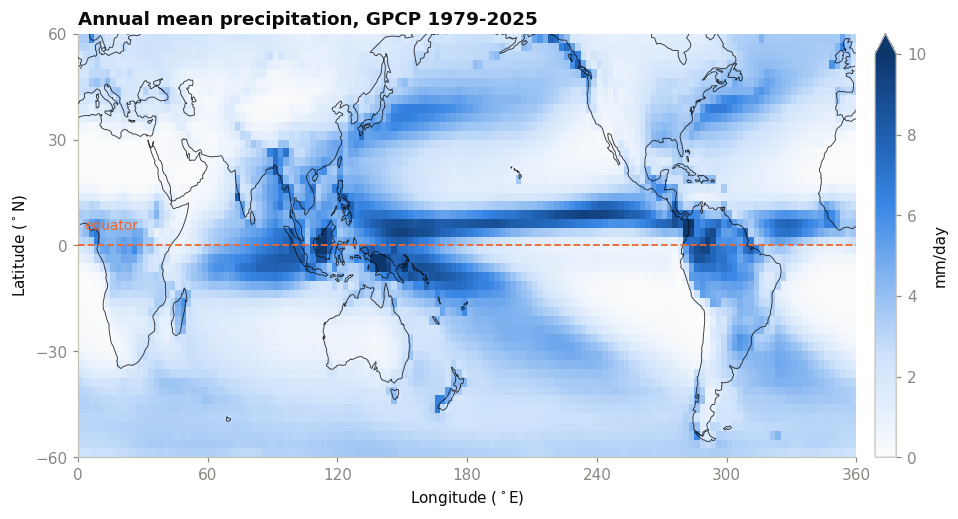

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))

mesh = ax.pcolormesh(clim.lon, clim.lat, annual_mean,
                     shading="auto", cmap=CMAP_RAIN, vmin=0, vmax=10)
draw_coastlines(ax, coastlines)
ax.axhline(0, color=C_ORANGE, lw=1.2, ls="--", zorder=4)
ax.text(3, 4.5, "equator", color=C_ORANGE, fontsize=9, zorder=4)

ax.set_xlim(0, 360); ax.set_ylim(-60, 60)
ax.set_xticks(np.arange(0, 361, 60)); ax.set_yticks(np.arange(-60, 61, 30))
ax.set_xlabel("Longitude ($^\\circ$E)"); ax.set_ylabel("Latitude ($^\\circ$N)")
ax.set_title(f"Annual mean precipitation, GPCP 1979-{last_full_year}")
ax.grid(False)
fig.colorbar(mesh, ax=ax, label="mm/day", pad=0.02, extend="max")
plt.show()

### Your turn — Question 1

> Look at the map for a full minute before writing anything. Then:
>
> **(a)** Describe the single most obvious feature in one sentence.
>
> **(b)** Is the dark band exactly on the equator? Check across the whole width
> of the map — is your answer the same over the eastern Pacific (longitudes
> 220–280) as over Africa (longitudes 10–40)?
>
> **(c)** Find two places that are almost black and two that are almost white.
> Name them if you can.

**Double-click here to type your answer, then press Shift+Enter.**

---

*(a)*

*(b)*

*(c)*

---
## 4. Make it move

A single annual-mean map hides the most important thing about this rainband: it
does not stay put.

The recipe below is worth keeping. Build the figure once, write an `update`
function that changes only what must change for each frame, and let
`FuncAnimation` call it twelve times.

In [10]:
month_names = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

fig, ax = plt.subplots(figsize=(11, 5))

mesh = ax.pcolormesh(clim.lon, clim.lat, clim.isel(month=0),
                     shading="auto", cmap=CMAP_RAIN, vmin=0, vmax=14)
draw_coastlines(ax, coastlines)
ax.axhline(0, color=C_ORANGE, lw=1.4, ls="--", zorder=4)
ax.set_xlim(0, 360); ax.set_ylim(-45, 45)
ax.set_xticks(np.arange(0, 361, 60)); ax.set_yticks(np.arange(-40, 41, 20))
ax.set_xlabel("Longitude ($^\\circ$E)"); ax.set_ylabel("Latitude ($^\\circ$N)")
ax.grid(False)
fig.colorbar(mesh, ax=ax, label="mm/day", pad=0.02, extend="max")
title = ax.set_title("Precipitation — January")


def update(frame):
    """Draw month number `frame` (0-11)."""
    mesh.set_array(clim.isel(month=frame).values.ravel())
    title.set_text(f"Precipitation — {month_names[frame]}")
    return mesh, title


anim = animation.FuncAnimation(fig, update, frames=12, interval=700, blit=False)
plt.close(fig)            # stops a duplicate static figure appearing below

HTML(anim.to_jshtml())

Use the controls: play it, then step frame by frame with the arrow buttons.
Watch **one longitude at a time** rather than the whole map — pick the eastern
Pacific (around 250°E, off Central America) and follow the band up and down.
Then do the same over Africa (around 20°E). They do not behave alike.

In [11]:
gif_path = Path("itcz_seasonal_cycle.gif")
anim.save(gif_path, writer=animation.PillowWriter(fps=2))
print(f"saved {gif_path}  ({gif_path.stat().st_size/1e6:.1f} MB)")
print("You can drop this into a slide or email it to someone.")

saved itcz_seasonal_cycle.gif  (1.4 MB)
You can drop this into a slide or email it to someone.


### Your turn — Question 2

> This is the most important question in the notebook. Take your time.
>
> **(a)** Describe what the rainband does through the year in your own words.
> Where is it in January? In July?
>
> **(b)** Over the **eastern Pacific** (around 250°E), how far south does the
> band get at its most southerly? Does it spend much of the year south of the
> equator there?
>
> **(c)** Now compare **Africa and the Indian Ocean** (20–90°E). Does the band
> behave the same way? Which region swings further?
>
> **(d)** Form a hypothesis. Why might the rainband swing much further over land
> than over the eastern Pacific? What is physically different about those two
> places? You are not expected to be right — you are expected to commit to a
> guess you can test later.

**Double-click here to type your answer.**

---

*(a)*

*(b)*

*(c)*

*(d) My hypothesis:*

---
## 5. Averaging away the longitudes

Maps are rich but hard to measure. Collapse the east–west direction by averaging
over longitude and you get a **zonal mean** — one number per latitude — which
turns "where is the rainband" into something you can put a number on.

**Choosing where to average is a scientific decision, not a formality.** We use
four regions, and two of them are both "the Pacific":

- **East Pacific (160°W–80°W)** — open ocean west of Central America. This is
  the region the double-ITCZ literature is about.
- **West Pacific (150°E–160°W)** — contains the South Pacific Convergence Zone,
  a great diagonal rainband that hangs *southeast* of the equator.

Watch what happens when we treat them separately.

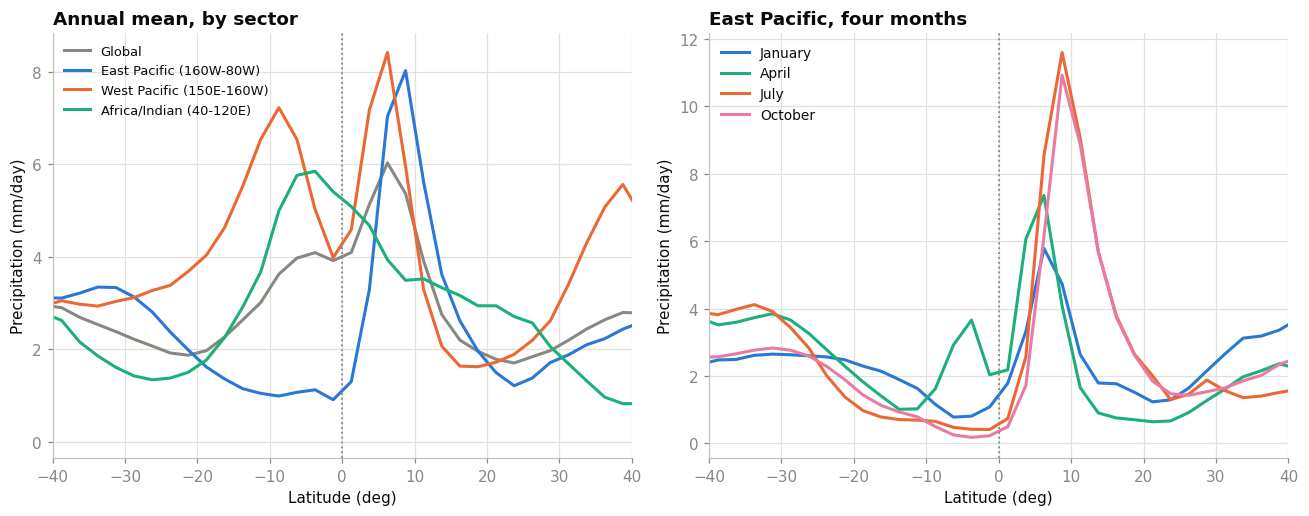

In [12]:
SECTORS = {
    "Global":                   (0, 360),
    "East Pacific (160W-80W)":  (200, 280),
    "West Pacific (150E-160W)": (150, 200),
    "Africa/Indian (40-120E)":  (40, 120),
}
SECTOR_COLORS = [C_MUTED, C_BLUE, C_ORANGE, C_AQUA]


def zonal_mean(da, lon_range):
    """Average over a longitude band."""
    lo, hi = lon_range
    return da.sel(lon=slice(lo, hi)).mean("lon")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

for (name, rng), col in zip(SECTORS.items(), SECTOR_COLORS):
    zm = zonal_mean(annual_mean, rng)
    ax1.plot(zm.lat, zm, color=col, label=name)

ax1.axvline(0, color=C_MUTED, ls=":", lw=1.2)
ax1.set_xlim(-40, 40); ax1.set_xlabel("Latitude (deg)")
ax1.set_ylabel("Precipitation (mm/day)")
ax1.set_title("Annual mean, by sector")
ax1.legend(loc="upper left", fontsize=8.5)

epac = zonal_mean(clim, SECTORS["East Pacific (160W-80W)"])
for m, col, lab in [(1, C_BLUE, "January"), (4, C_AQUA, "April"),
                    (7, C_ORANGE, "July"), (10, C_MAGENTA, "October")]:
    ax2.plot(epac.lat, epac.sel(month=m), color=col, label=lab)
ax2.axvline(0, color=C_MUTED, ls=":", lw=1.2)
ax2.set_xlim(-40, 40); ax2.set_xlabel("Latitude (deg)")
ax2.set_ylabel("Precipitation (mm/day)")
ax2.set_title("East Pacific, four months")
ax2.legend(loc="upper left", fontsize=9)

plt.tight_layout(); plt.show()

### Your turn — Question 3

> **(a)** In the left panel, the East Pacific curve has one clear peak. Read off
> roughly what latitude it is at. North or south of the equator?
>
> **(b)** The West Pacific curve peaks somewhere different. Where? These are both
> "the Pacific" — what does that tell you about how carefully you have to define
> a region before quoting a number from it?
>
> **(c)** In the right panel, does the East Pacific peak ever cross into the
> southern hemisphere in any of the four months shown?

**Double-click here to type your answer.**

---

*(a)*

*(b)*

*(c)*

---
## 6. Putting a number on it

"The band sits a bit north" is an observation. Research needs a number. Two
standard ones:

**The precipitation centroid** — the rainfall-weighted mean latitude over the
deep tropics (±20°):

$$\phi_{\mathrm{cent}} \;=\; \frac{\displaystyle\int_{-20^\circ}^{20^\circ} \phi\,P(\phi)\,\cos\phi\;\mathrm{d}\phi}
                                   {\displaystyle\int_{-20^\circ}^{20^\circ} P(\phi)\,\cos\phi\;\mathrm{d}\phi}$$

This is a centre of mass with rainfall playing the role of mass. If rain were
distributed symmetrically about the equator it would be exactly zero.

**The hemispheric asymmetry index** — how lopsided the tropical rainbelt is:

$$\mathrm{AI} \;=\; \frac{P_{\mathrm{NH}} - P_{\mathrm{SH}}}{P_{\mathrm{NH}} + P_{\mathrm{SH}}}$$

with $P_{\mathrm{NH}}$, $P_{\mathrm{SH}}$ the area-weighted mean rainfall in
0–20°N and 20°S–0. AI = 0 means perfectly symmetric; AI > 0 means the north is
wetter. It is dimensionless, so it compares cleanly across datasets and models.

Both carry $\cos\phi$ weights, for the same reason as before: a grid box at the
equator covers more area than one at 20°.

In [13]:
def precip_centroid(zm, bound=20.0):
    """Rainfall-weighted mean latitude within +/- bound degrees."""
    sel = zm.sel(lat=slice(-bound, bound))      # safe: we sorted lat ascending
    w = np.cos(np.deg2rad(sel.lat))
    return (sel * sel.lat * w).sum("lat") / (sel * w).sum("lat")


def asymmetry_index(zm, bound=20.0):
    """(NH - SH) / (NH + SH) over the deep tropics, area weighted."""
    def band(south, north):
        sel = zm.sel(lat=slice(south, north))
        w = np.cos(np.deg2rad(sel.lat))
        return (sel * w).sum("lat") / w.sum()
    nh, sh = band(0, bound), band(-bound, 0)
    return (nh - sh) / (nh + sh)


print(f"{'sector':<27}{'centroid':>11}{'AI':>9}{'peak':>9}{'at':>8}")
print("-" * 64)
for name, rng in SECTORS.items():
    zm = zonal_mean(annual_mean, rng)
    print(f"{name:<27}{float(precip_centroid(zm)):>9.2f} N"
          f"{float(asymmetry_index(zm)):>9.3f}"
          f"{float(zm.max()):>8.2f}  {float(zm.idxmax('lat')):>+6.1f}")

sector                        centroid       AI     peak      at
----------------------------------------------------------------
Global                          0.75 N    0.105    6.03    +6.2
East Pacific (160W-80W)         5.15 N    0.569    8.03    +8.8
West Pacific (150E-160W)       -2.11 N   -0.108    8.43    +6.2
Africa/Indian (40-120E)         0.16 N   -0.041    5.85    -3.8


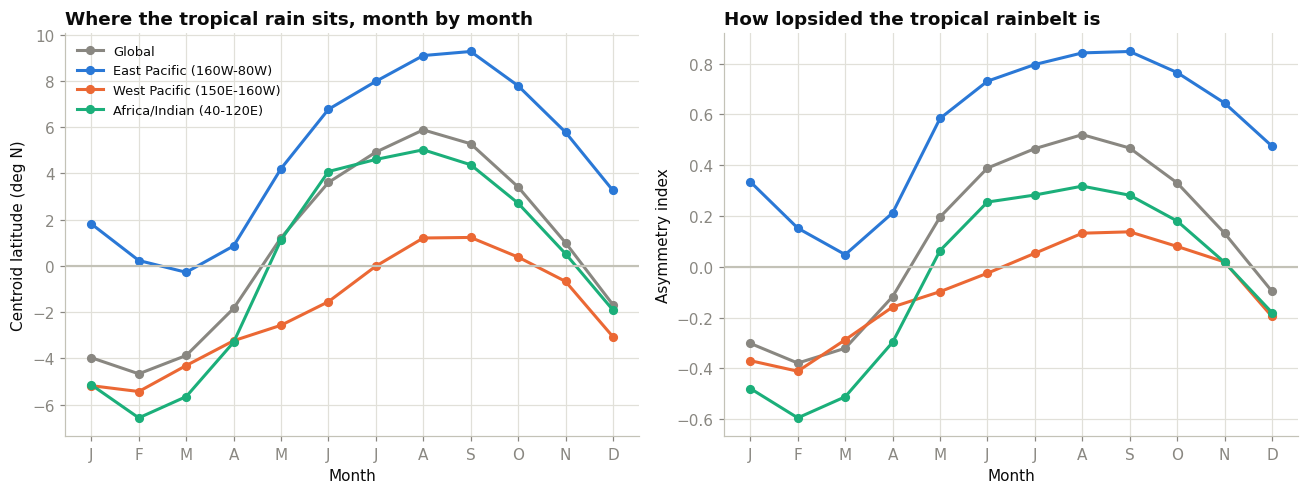

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
months = np.arange(1, 13)

for (name, rng), col in zip(SECTORS.items(), SECTOR_COLORS):
    zm = zonal_mean(clim, rng)
    ax1.plot(months, precip_centroid(zm), color=col, marker="o", ms=5, label=name)
    ax2.plot(months, asymmetry_index(zm), color=col, marker="o", ms=5, label=name)

for ax, ylab, title in [
        (ax1, "Centroid latitude (deg N)", "Where the tropical rain sits, month by month"),
        (ax2, "Asymmetry index", "How lopsided the tropical rainbelt is")]:
    ax.axhline(0, color="#c3c2b7", lw=1.4)
    ax.set_xticks(months)
    ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
    ax.set_xlabel("Month"); ax.set_ylabel(ylab); ax.set_title(title)
ax1.legend(loc="upper left", fontsize=8.5)

plt.tight_layout(); plt.show()

### Your turn — Question 4

> **(a)** Write down the **annual mean centroid latitude and asymmetry index for
> the East Pacific**. You will compare climate models against these two numbers
> later, so record them properly.
>
> **(b)** Does the East Pacific centroid ever go negative? Does the West Pacific
> one? Explain the difference in terms of what you saw on the map.
>
> **(c)** Which sector has the largest seasonal swing, and by how many degrees?
> Does that match the hypothesis you wrote in Question 2(d)?
>
> **(d)** The East Pacific asymmetry index is positive in every month. Say in one
> sentence what that means physically, without using the word "index".

**Double-click here to type your answer.**

---

*(a) centroid = ______ °N,  AI = ______*

*(b)*

*(c)*

*(d)*

---
## 7. One picture of the whole seasonal cycle

A **Hovmöller diagram** puts latitude on one axis and time on the other, so an
entire seasonal migration fits in one frame. East Pacific, with the centroid
laid on top.

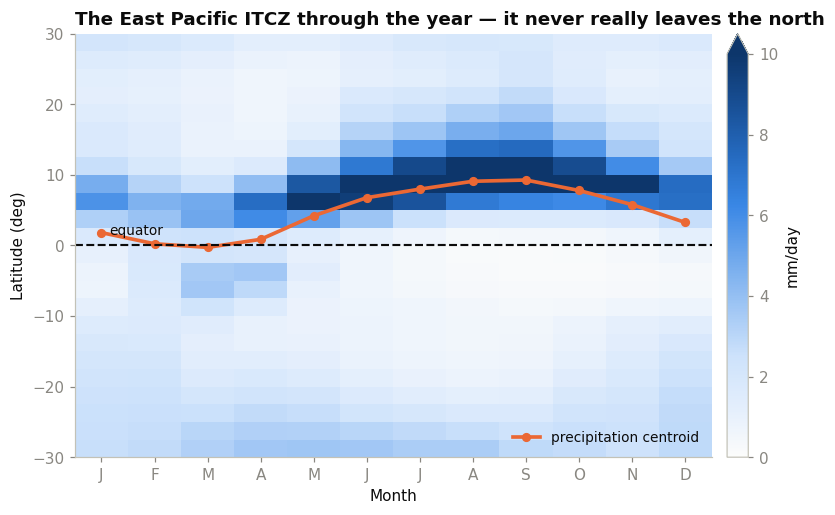

In [15]:
epac_clim = zonal_mean(clim, SECTORS["East Pacific (160W-80W)"])
cent = precip_centroid(epac_clim)

fig, ax = plt.subplots(figsize=(9, 5))

mesh = ax.pcolormesh(months, epac_clim.lat, epac_clim.T,
                     shading="auto", cmap=CMAP_RAIN, vmin=0, vmax=10)
ax.plot(months, cent, color=C_ORANGE, lw=2.4, marker="o", ms=5,
        label="precipitation centroid")
ax.axhline(0, color=C_INK, lw=1.4, ls="--")
ax.text(1.15, 1.6, "equator", color=C_INK, fontsize=9)

ax.set_ylim(-30, 30); ax.set_xticks(months)
ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_xlabel("Month"); ax.set_ylabel("Latitude (deg)")
ax.set_title("The East Pacific ITCZ through the year — it never really leaves the north")
ax.legend(loc="lower right", fontsize=9)
ax.grid(False)
fig.colorbar(mesh, ax=ax, label="mm/day", pad=0.02, extend="max")
plt.show()

---
## 8. The question this whole project is about

You have now established, from data rather than from a textbook, that:

- There is a narrow band of very heavy rain in the tropics — the
  **Intertropical Convergence Zone**, the ITCZ.
- Over the **eastern Pacific** it sits **north of the equator**, in a **single**
  band, and it stays north in every month of the year.
- Over land and over the western Pacific it behaves quite differently.

Here is why that matters.

**Nearly every coupled climate model ever built gets the eastern Pacific wrong.**
Models produce a second, spurious rainband south of the equator, roughly
mirroring the real one. Instead of one band around 6–9°N, they make two. This is
the **double-ITCZ bias**. It has survived CMIP3, CMIP5 and CMIP6 largely intact,
it is arguably the longest-standing systematic error in climate modelling, and it
contaminates model projections of tropical rainfall, monsoons and El Niño.

The two numbers you just computed are exactly how that bias is measured. A model
with a double ITCZ has an East Pacific centroid near zero and an asymmetry index
near zero, because its rain is far too symmetric about the equator. You now have
the observational target those models are failing to hit.

### Your turn — Question 5

> Before reading any further in this project, commit to a guess.
>
> **(a)** Why do you think the real ITCZ prefers the northern hemisphere over the
> eastern Pacific? What could possibly distinguish north from south there?
>
> **(b)** If a climate model puts rain on both sides of the equator instead, what
> do you think it is getting wrong about the real world?
>
> **(c)** What one extra piece of data would you most want to look at next, to
> test your answer to (a)?
>
> Write your guesses down **now**, and date them. At the end of the project come
> back and see how you did. This is not a formality: being wrong in a way you can
> point at afterwards is how you find out what a field actually knows.

**Double-click here to type your answer.**

---

*Date:*

*(a)*

*(b)*

*(c)*

---
## What you just did

You opened a real 47-year satellite dataset, hit a genuine defect in it and
worked around it, checked its coordinate conventions before trusting them,
collapsed it into a seasonal climatology with `groupby`, drew maps with correct
coastlines, animated the seasonal cycle, computed area-weighted zonal means, and
implemented two research-standard diagnostics from their mathematical
definitions.

That is a real observational analysis workflow, not a teaching exercise dressed
up as one. The rest of this project reuses all of it, applied to model output.

**Next:** Notebooks 01–03 build the physics — why a planet has a temperature at
all, where sunlight falls, and what sets the latitude of the rainband you just
measured. Notebook 03 in particular predicts the number you wrote down in
Question 4(a) from energy conservation alone, and you will be in a position to
judge how well it does.

---
## Exercises

Write these in new cells at the bottom. Copy an existing cell and change it —
that is how everyone starts.

**1. Your own sector.** Add the Atlantic (longitudes 300–360) to `SECTORS` and
re-run sections 5 and 6. Is the Atlantic ITCZ more like the East Pacific or more
like Africa?

**2. Wettest and driest.** Find the latitude and longitude of the wettest grid
cell in the annual mean, and of the driest. (Look up `.idxmax()` and `.argmax()`,
or use `np.unravel_index`.) Do the locations make sense to you?

**3. Does the band change shape, or just move?** For each month, compute the full
width at half maximum of the East Pacific rainfall profile and plot it against
month. Does the ITCZ widen as it migrates, or simply translate?

**4. How steady is it?** We averaged 47 years together. Instead, compute the East
Pacific centroid for each individual year and plot the time series. How much does
it wobble? Is there a trend? (Hint: `precip.groupby("time.year").mean("time")`.)

**5. El Niño.** 1982–83, 1997–98 and 2015–16 were strong El Niño years. Plot the
East Pacific rainfall profile for those years against the average of all other
years. What happens to the ITCZ during El Niño, and why might that matter for a
model that already has a double-ITCZ problem?

**6. A better animation.** Modify the animation to show the *anomaly* from the
annual mean (`clim - annual_mean`) using `CMAP_DIV` with symmetric limits. Which
version tells the seasonal story more clearly, and why? Keep whichever you
prefer — and be able to defend the choice.